In [2]:
# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


In [3]:
# Load California Housing Dataset
housing = fetch_california_housing()

X = housing.data
y = housing.target

In [4]:
# Feature Scaling
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,y,test_size=0.2,random_state=42)

In [5]:

# Build ANN Model
model = Sequential()

model.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))
model.add(Dropout(0.2))

model.add(Dense(32, activation='relu'))
model.add(Dropout(0.2))

model.add(Dense(1))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [6]:

# Compile Model
model.compile(
    optimizer='adam',
    loss='mean_squared_error',
    metrics=['mae']
)

# Train Model
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 1.1023 - mae: 0.7331 - val_loss: 0.5054 - val_mae: 0.4907
Epoch 2/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6285 - mae: 0.5559 - val_loss: 0.4465 - val_mae: 0.4719
Epoch 3/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5210 - mae: 0.5158 - val_loss: 0.4250 - val_mae: 0.4550
Epoch 4/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4952 - mae: 0.5017 - val_loss: 0.4095 - val_mae: 0.4417
Epoch 5/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4648 - mae: 0.4856 - val_loss: 0.4044 - val_mae: 0.4370
Epoch 6/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4531 - mae: 0.4747 - val_loss: 0.4073 - val_mae: 0.4356
Epoch 7/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4560 - mae: 0.4707 - val_loss: 0.3984 - val_mae: 0.4259
Epoch 8/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4177 - mae: 0.4594 - val_loss: 0.3818 - val_mae: 0.4283
Epoch 9/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - lo

In [7]:
y_pred = model.predict(X_test)

# Evaluation
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("Mean Absolute Error:", mae)
print("R2 Score:", r2)

129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Mean Squared Error: 0.2955116941322631
Mean Absolute Error: 0.3718293495305841
R2 Score: 0.7744889579977088


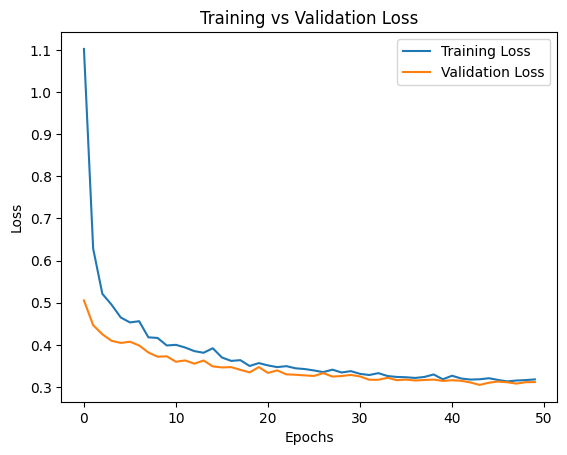

In [8]:

# Plot Training Loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.show()